# NB02b: Provider Practice Settings (National & State-Level)

**Purpose:** Show the distribution of behavioral health providers across practice settings
(private practice / small group vs. outpatient centers vs. psychiatric hospitals vs. other)
using BLS OEWS state-level data by industry (Sector 62). This provides **descriptive background context** for the
expansion analysis, and enables **state-level comparison** of practice-setting composition.

**This data is NOT used as a scoring dimension.** The expansion scoring model (NB07) uses
total provider density from NB02 as its provider dimension. Practice-setting composition is
presented in the blog Background section to give readers a fuller picture of the behavioral
health workforce.

**Important caveat:** This data describes *where providers are employed*, not whether they
are available or willing to join a telehealth platform. Providers in any setting — private
practice, hospital-employed, or outpatient center — can supplement their caseload through
platforms like Octave via 1099 contractor arrangements.

**Data Source:** [BLS Occupational Employment and Wage Statistics (OEWS) Research Estimates by State and Industry](https://www.bls.gov/oes/),
May 2024 release. State × industry file: `oes_research_2024_sec_62.xlsx`.
Sector 62 covers all of Health Care and Social Assistance. Downloaded from BLS Research Estimates data.

**Data Granularity:** State-level (54 areas: 50 states + DC + territories). Includes detailed NAICS codes
for practice settings: private practice (621330), outpatient MH centers (621420), psychiatric hospitals (622200),
and sector-level totals (62) for residual "other" employment.

**Output:** 
- `provider_practice_settings_national.csv` — national rollup of state data, employment counts and percentages by practice setting
- `practice_settings_by_occupation.csv` — national-level breakdown by occupation and setting
- `practice_settings_by_state.csv` — state-level employment counts, percentages, and Octave status for each setting

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Configuration ---
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw', 'bls_oes')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb02b_provider_practice_settings')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"BLS data dir: {DATA_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

# Verify data file exists
state_file = os.path.join(DATA_DIR, 'oes_research_2024_sec_62.xlsx')
if os.path.exists(state_file):
    print(f"  ✓ oes_research_2024_sec_62.xlsx ({os.path.getsize(state_file) / 1e6:.1f} MB)")
else:
    print(f"  ✗ oes_research_2024_sec_62.xlsx — MISSING")

Project root: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion
BLS data dir: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/raw/bls_oes
Output dir: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb02b_provider_practice_settings
  ✓ oes_research_2024_sec_62.xlsx (16.7 MB)


## 1. Load State-Level Data

In [2]:
# --- Load state-level data ---
df = pd.read_excel(os.path.join(DATA_DIR, 'oes_research_2024_sec_62.xlsx'))
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

# Standardize key columns
df['NAICS'] = df['NAICS'].astype(str).str.strip()
df['OCC_CODE'] = df['OCC_CODE'].astype(str).str.strip()
df['TOT_EMP'] = pd.to_numeric(df['TOT_EMP'], errors='coerce')

print(f"\nUnique I_GROUP values: {df['I_GROUP'].unique().tolist()}")
print(f"Unique O_GROUP values: {df['O_GROUP'].unique().tolist()}")
print(f"Unique AREA (state) count: {df['AREA'].nunique()}")
print(f"Unique NAICS codes: {df['NAICS'].nunique()}")
print(f"Unique OCC_CODE values: {df['OCC_CODE'].nunique()}")

Shape: 99,338 rows, 26 columns

Columns: ['AREA', 'AREA_TITLE', 'NAICS', 'NAICS_TITLE', 'I_GROUP', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP', 'EMP_PRSE', 'PCT_TOTAL', 'H_MEAN', 'A_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90', 'ANNUAL', 'HOURLY']

Unique I_GROUP values: ['sector', '3-digit', '4-digit', '5-digit']
Unique O_GROUP values: ['total', 'major', 'detailed']
Unique AREA (state) count: 54
Unique NAICS codes: 34
Unique OCC_CODE values: 442


## 2. Filter to Behavioral Health Providers

In [3]:
# --- Define behavioral health SOC codes ---
BH_SOC_CODES = [
    '21-1018',  # Substance Abuse, Behavioral Disorder, and Mental Health Counselors
    '21-1023',  # Mental Health and Substance Abuse Social Workers
    '19-3033',  # Clinical and Counseling Psychologists
    '29-1223',  # Psychiatrists
]

# Filter to BH occupations and sector/3-digit NAICS levels for practice settings
# We need:
# - NAICS='62' (sector total) at appropriate I_GROUP
# - NAICS='621330', '621420', '622200' for specific practice settings
df_bh = df[df['OCC_CODE'].isin(BH_SOC_CODES)].copy()
print(f"Rows with BH occupations: {len(df_bh):,}")
print(f"Unique AREA values in BH data: {df_bh['AREA'].nunique()}")
print(f"\nSample data:")
print(df_bh[['AREA_TITLE', 'NAICS', 'NAICS_TITLE', 'OCC_CODE', 'OCC_TITLE', 'I_GROUP', 'O_GROUP', 'TOT_EMP']].head(15))

Rows with BH occupations: 2,302
Unique AREA values in BH data: 52

Sample data:
    AREA_TITLE NAICS                        NAICS_TITLE OCC_CODE  \
45     Alabama    62  Health Care and Social Assistance  19-3033   
51     Alabama    62  Health Care and Social Assistance  21-1018   
54     Alabama    62  Health Care and Social Assistance  21-1023   
254     Alaska    62  Health Care and Social Assistance  19-3033   
259     Alaska    62  Health Care and Social Assistance  21-1018   
262     Alaska    62  Health Care and Social Assistance  21-1023   
299     Alaska    62  Health Care and Social Assistance  29-1223   
441    Arizona    62  Health Care and Social Assistance  19-3033   
450    Arizona    62  Health Care and Social Assistance  21-1018   
453    Arizona    62  Health Care and Social Assistance  21-1023   
504    Arizona    62  Health Care and Social Assistance  29-1223   
684   Arkansas    62  Health Care and Social Assistance  19-3033   
691   Arkansas    62  Health Care an

In [4]:
# --- Build per-state summary for each practice setting ---
# For each state and each BH occupation code, extract employment by NAICS

state_rows = []
area_unique = df_bh[['AREA', 'AREA_TITLE']].drop_duplicates().sort_values('AREA')

for _, area_row in area_unique.iterrows():
    area_code = area_row['AREA']
    area_title = area_row['AREA_TITLE']
    
    # Get all BH employment for this state
    df_state = df_bh[df_bh['AREA'] == area_code]
    
    # Sum across BH SOC codes and occupation levels to get employment by NAICS
    # Filter to 'detailed' O_GROUP (occupation-level rows, not totals)
    # and 'sector'/'3-digit'/'4-digit'/'5-digit' I_GROUP depending on NAICS
    df_detailed = df_state[df_state['O_GROUP'] == 'detailed']
    
    # Get employment for each practice setting NAICS
    pp = df_detailed[df_detailed['NAICS'] == '621330']['TOT_EMP'].sum()
    pp = pp if pd.notna(pp) and pp > 0 else 0
    
    oc = df_detailed[df_detailed['NAICS'] == '621420']['TOT_EMP'].sum()
    oc = oc if pd.notna(oc) and oc > 0 else 0
    
    ph = df_detailed[df_detailed['NAICS'] == '622200']['TOT_EMP'].sum()
    ph = ph if pd.notna(ph) and ph > 0 else 0
    
    # Total from sector-level (NAICS='62')
    total = df_detailed[df_detailed['NAICS'] == '62']['TOT_EMP'].sum()
    total = total if pd.notna(total) and total > 0 else 0
    
    # Residual: other settings
    other = total - pp - oc - ph
    other = max(0, other)  # Handle negative residuals
    
    state_rows.append({
        'area': area_code,
        'area_title': area_title,
        'total_bh': total,
        'private_practice': pp,
        'outpatient_centers': oc,
        'psych_hospitals': ph,
        'other_settings': other,
    })

df_state_summary = pd.DataFrame(state_rows)
print(f"State summary rows: {len(df_state_summary)}")
print(f"\nFirst 10 states:")
print(df_state_summary.head(10))

State summary rows: 52

First 10 states:
   area            area_title  total_bh  private_practice  outpatient_centers  \
0     1               Alabama    3230.0             440.0               890.0   
1     2                Alaska    1210.0              90.0               190.0   
2     4               Arizona   12630.0            2300.0              3420.0   
3     5              Arkansas    3860.0             680.0              1020.0   
4     6            California   69430.0           16950.0             12150.0   
5     8              Colorado   16440.0            5440.0              3340.0   
6     9           Connecticut    6750.0             910.0              1300.0   
7    10              Delaware    1420.0             110.0               170.0   
8    11  District of Columbia    1810.0               0.0               280.0   
9    12               Florida   30550.0            6010.0              6410.0   

   psych_hospitals  other_settings  
0            360.0          15

In [5]:
# --- Add percentage columns ---
df_state_summary['private_practice_pct'] = (df_state_summary['private_practice'] / df_state_summary['total_bh'] * 100).round(1)
df_state_summary['outpatient_centers_pct'] = (df_state_summary['outpatient_centers'] / df_state_summary['total_bh'] * 100).round(1)
df_state_summary['psych_hospitals_pct'] = (df_state_summary['psych_hospitals'] / df_state_summary['total_bh'] * 100).round(1)
df_state_summary['other_settings_pct'] = (df_state_summary['other_settings'] / df_state_summary['total_bh'] * 100).round(1)

print("State-level summary with percentages:")
print(df_state_summary[['area_title', 'total_bh', 'private_practice_pct', 'outpatient_centers_pct', 'psych_hospitals_pct', 'other_settings_pct']].head(15))

State-level summary with percentages:
              area_title  total_bh  private_practice_pct  \
0                Alabama    3230.0                  13.6   
1                 Alaska    1210.0                   7.4   
2                Arizona   12630.0                  18.2   
3               Arkansas    3860.0                  17.6   
4             California   69430.0                  24.4   
5               Colorado   16440.0                  33.1   
6            Connecticut    6750.0                  13.5   
7               Delaware    1420.0                   7.7   
8   District of Columbia    1810.0                   0.0   
9                Florida   30550.0                  19.7   
10               Georgia    8680.0                  33.6   
11                Hawaii    1940.0                  21.1   
12                 Idaho    2630.0                  25.1   
13              Illinois   22160.0                  23.6   
14               Indiana   12220.0                  16.3   

 

## 3. Merge with Octave State Classification

In [6]:
# --- Load Octave state classification from NB02 output ---
octave_file = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb02_provider_landscape', 'state_provider_counts.csv')
df_octave = pd.read_csv(octave_file)
print(f"Octave classification file loaded: {len(df_octave)} rows")
print(f"Columns: {df_octave.columns.tolist()[:5]}...")

# Merge on state name
# First, map AREA_TITLE to state_name
octave_state_map = dict(zip(df_octave['state_name'], df_octave['is_octave_state']))
df_state_summary['is_octave_state'] = df_state_summary['area_title'].map(octave_state_map).fillna(False).astype(bool)

print(f"\nOctave vs. Expansion states:")
print(f"  Octave states: {df_state_summary['is_octave_state'].sum()}")
print(f"  Expansion states: {(~df_state_summary['is_octave_state']).sum()}")
print(f"\nOctave state list:")
print(df_state_summary[df_state_summary['is_octave_state'] == True]['area_title'].tolist())

Octave classification file loaded: 51 rows
Columns: ['state_name', 'state_abbrev', 'fips_code', 'is_octave_state', 'psychiatrists']...

Octave vs. Expansion states:
  Octave states: 23
  Expansion states: 29

Octave state list:
['Arizona', 'California', 'Colorado', 'Connecticut', 'District of Columbia', 'Florida', 'Georgia', 'Illinois', 'Maryland', 'Massachusetts', 'Minnesota', 'New Jersey', 'New York', 'North Carolina', 'Ohio', 'Oregon', 'Pennsylvania', 'South Carolina', 'Tennessee', 'Texas', 'Virginia', 'Washington', 'Wisconsin']


/var/folders/0d/xqmptt6x035b25m88r2ffc9m0000gn/T/ipykernel_76917/175050189.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_state_summary['is_octave_state'] = df_state_summary['area_title'].map(octave_state_map).fillna(False).astype(bool)


## 4. National Summary (from state-level rollup)

In [7]:
# --- Roll up to national totals ---
total_bh = df_state_summary['total_bh'].sum()
total_pp = df_state_summary['private_practice'].sum()
total_oc = df_state_summary['outpatient_centers'].sum()
total_ph = df_state_summary['psych_hospitals'].sum()
total_other = df_state_summary['other_settings'].sum()

national_settings = {
    'Private Practice / Small Group': total_pp,
    'Outpatient MH Centers': total_oc,
    'Psychiatric Hospitals': total_ph,
    'Other Settings': total_other,
}

print(f"{'='*70}")
print(f"NATIONAL PRACTICE-SETTING DISTRIBUTION (from state-level rollup)")
print(f"{'='*70}")
print(f"{'Setting':<35} {'Employment':>15} {'Share':>10}")
print(f"{'-'*60}")
for label, emp in national_settings.items():
    pct = emp / total_bh * 100
    print(f"{label:<35} {emp:>15,.0f} {pct:>9.1f}%")
print(f"{'-'*60}")
print(f"{'TOTAL':<35} {total_bh:>15,.0f} {'100.0%':>10}")
print(f"{'='*70}")

NATIONAL PRACTICE-SETTING DISTRIBUTION (from state-level rollup)
Setting                                  Employment      Share
------------------------------------------------------------
Private Practice / Small Group              108,780      20.2%
Outpatient MH Centers                       110,910      20.6%
Psychiatric Hospitals                        26,830       5.0%
Other Settings                              291,480      54.2%
------------------------------------------------------------
TOTAL                                       538,000     100.0%


## 5. State-Level Practice Setting Distribution

In [8]:
# --- Compare states: top and bottom by private practice share ---
df_ranked = df_state_summary.sort_values('private_practice_pct', ascending=False).reset_index(drop=True)

print(f"\n{'='*90}")
print(f"TOP 10 STATES BY PRIVATE PRACTICE SHARE")
print(f"{'='*90}")
print(f"{'Rank':<4} {'State':<25} {'Private %':>10} {'Outpat %':>10} {'Hosp %':>10} {'Other %':>10}")
print(f"{'-'*90}")
for idx, row in df_ranked.head(10).iterrows():
    status = "[Octave]" if row['is_octave_state'] else "[Expansion]"
    print(f"{idx+1:<4} {row['area_title']:<25} {row['private_practice_pct']:>9.1f}% {row['outpatient_centers_pct']:>9.1f}% {row['psych_hospitals_pct']:>9.1f}% {row['other_settings_pct']:>9.1f}%")

print(f"\n{'='*90}")
print(f"BOTTOM 10 STATES BY PRIVATE PRACTICE SHARE")
print(f"{'='*90}")
print(f"{'Rank':<4} {'State':<25} {'Private %':>10} {'Outpat %':>10} {'Hosp %':>10} {'Other %':>10}")
print(f"{'-'*90}")
for idx, row in df_ranked.tail(10).iterrows():
    status = "[Octave]" if row['is_octave_state'] else "[Expansion]"
    print(f"{53-idx:<4} {row['area_title']:<25} {row['private_practice_pct']:>9.1f}% {row['outpatient_centers_pct']:>9.1f}% {row['psych_hospitals_pct']:>9.1f}% {row['other_settings_pct']:>9.1f}%")


TOP 10 STATES BY PRIVATE PRACTICE SHARE
Rank State                      Private %   Outpat %     Hosp %    Other %
------------------------------------------------------------------------------------------
1    Georgia                        33.6%      18.7%       5.2%      42.5%
2    Colorado                       33.1%      20.3%       5.2%      41.4%
3    Wyoming                        32.6%      31.5%       0.0%      35.9%
4    Utah                           30.8%      14.5%       0.5%      54.3%
5    Michigan                       29.3%      14.8%       1.7%      54.2%
6    Tennessee                      26.1%      24.6%       7.9%      41.4%
7    Virginia                       25.1%      18.2%       5.3%      51.4%
8    Idaho                          25.1%      22.8%       0.0%      52.1%
9    Oregon                         24.9%      17.5%       2.3%      55.3%
10   New York                       24.8%      13.9%       4.9%      56.4%

BOTTOM 10 STATES BY PRIVATE PRACTICE SHARE

In [9]:
# --- Octave vs. Expansion state comparison ---
df_octave_grp = df_state_summary[df_state_summary['is_octave_state'] == True]
df_expansion_grp = df_state_summary[df_state_summary['is_octave_state'] == False]

comparison = {
    'Octave States': {
        'Count': len(df_octave_grp),
        'Private Practice (mean %)': df_octave_grp['private_practice_pct'].mean(),
        'Outpatient Centers (mean %)': df_octave_grp['outpatient_centers_pct'].mean(),
        'Psych Hospitals (mean %)': df_octave_grp['psych_hospitals_pct'].mean(),
        'Other Settings (mean %)': df_octave_grp['other_settings_pct'].mean(),
    },
    'Expansion States': {
        'Count': len(df_expansion_grp),
        'Private Practice (mean %)': df_expansion_grp['private_practice_pct'].mean(),
        'Outpatient Centers (mean %)': df_expansion_grp['outpatient_centers_pct'].mean(),
        'Psych Hospitals (mean %)': df_expansion_grp['psych_hospitals_pct'].mean(),
        'Other Settings (mean %)': df_expansion_grp['other_settings_pct'].mean(),
    },
}

print(f"\n{'='*80}")
print(f"OCTAVE vs. EXPANSION STATE COMPARISON (Mean Practice Settings %)")
print(f"{'='*80}")
print(f"{'Metric':<35} {'Octave States':>20} {'Expansion States':>20}")
print(f"{'-'*80}")
for metric in ['Count', 'Private Practice (mean %)', 'Outpatient Centers (mean %)', 'Psych Hospitals (mean %)', 'Other Settings (mean %)']:
    octave_val = comparison['Octave States'][metric]
    exp_val = comparison['Expansion States'][metric]
    if metric == 'Count':
        print(f"{metric:<35} {octave_val:>20.0f} {exp_val:>20.0f}")
    else:
        print(f"{metric:<35} {octave_val:>20.1f}% {exp_val:>20.1f}%")
print(f"{'='*80}")


OCTAVE vs. EXPANSION STATE COMPARISON (Mean Practice Settings %)
Metric                                     Octave States     Expansion States
--------------------------------------------------------------------------------
Count                                                 23                   29
Private Practice (mean %)                           19.7%                 16.6%
Outpatient Centers (mean %)                         19.9%                 20.6%
Psych Hospitals (mean %)                             5.1%                  4.2%
Other Settings (mean %)                             55.3%                 58.6%


## 6. By-Occupation Breakdown (National)

In [10]:
# --- Build by-occupation breakdown (sum all states) ---
OCC_LABELS = {
    '19-3033': 'Clinical & Counseling Psychologists',
    '21-1018': 'MH Counselors & SA Counselors',
    '21-1023': 'MH & SA Social Workers',
    '29-1223': 'Psychiatrists',
}

occ_rows = []
for occ_code, occ_label in OCC_LABELS.items():
    df_occ = df_bh[df_bh['OCC_CODE'] == occ_code]
    df_occ_detailed = df_occ[df_occ['O_GROUP'] == 'detailed']
    
    pp = df_occ_detailed[df_occ_detailed['NAICS'] == '621330']['TOT_EMP'].sum()
    pp = pp if pd.notna(pp) and pp > 0 else 0
    
    oc = df_occ_detailed[df_occ_detailed['NAICS'] == '621420']['TOT_EMP'].sum()
    oc = oc if pd.notna(oc) and oc > 0 else 0
    
    ph = df_occ_detailed[df_occ_detailed['NAICS'] == '622200']['TOT_EMP'].sum()
    ph = ph if pd.notna(ph) and ph > 0 else 0
    
    total = df_occ_detailed[df_occ_detailed['NAICS'] == '62']['TOT_EMP'].sum()
    total = total if pd.notna(total) and total > 0 else 0
    
    other = total - pp - oc - ph
    other = max(0, other)
    
    occ_rows.append({
        'occupation': occ_label,
        'soc_code': occ_code,
        'private_practice': pp,
        'outpatient_centers': oc,
        'psych_hospitals': ph,
        'other_settings': other,
        'total': total,
        'private_practice_pct': round(pp / total * 100, 1) if total > 0 else 0,
        'outpatient_centers_pct': round(oc / total * 100, 1) if total > 0 else 0,
        'psych_hospitals_pct': round(ph / total * 100, 1) if total > 0 else 0,
        'other_settings_pct': round(other / total * 100, 1) if total > 0 else 0,
    })

df_by_occ = pd.DataFrame(occ_rows)

print(f"\n{'='*100}")
print(f"PRACTICE SETTINGS BY OCCUPATION (National)")
print(f"{'='*100}")
print(f"{'Occupation':<40} {'Private %':>10} {'Outpat %':>10} {'Hosp %':>10} {'Other %':>10} {'Total':>12}")
print(f"{'-'*100}")
for _, r in df_by_occ.iterrows():
    print(f"{r['occupation']:<40} {r['private_practice_pct']:>9.1f}% {r['outpatient_centers_pct']:>9.1f}% {r['psych_hospitals_pct']:>9.1f}% {r['other_settings_pct']:>9.1f}% {r['total']:>12,.0f}")
print(f"{'='*100}")


PRACTICE SETTINGS BY OCCUPATION (National)
Occupation                                Private %   Outpat %     Hosp %    Other %        Total
----------------------------------------------------------------------------------------------------
Clinical & Counseling Psychologists           45.0%       5.9%       3.0%      46.1%       61,060
MH Counselors & SA Counselors                 19.1%      23.2%       4.5%      53.2%      357,360
MH & SA Social Workers                        12.9%      22.8%       7.7%      56.6%       99,590
Psychiatrists                                  1.6%       7.7%       7.0%      83.7%       19,990


## 7. Visualizations

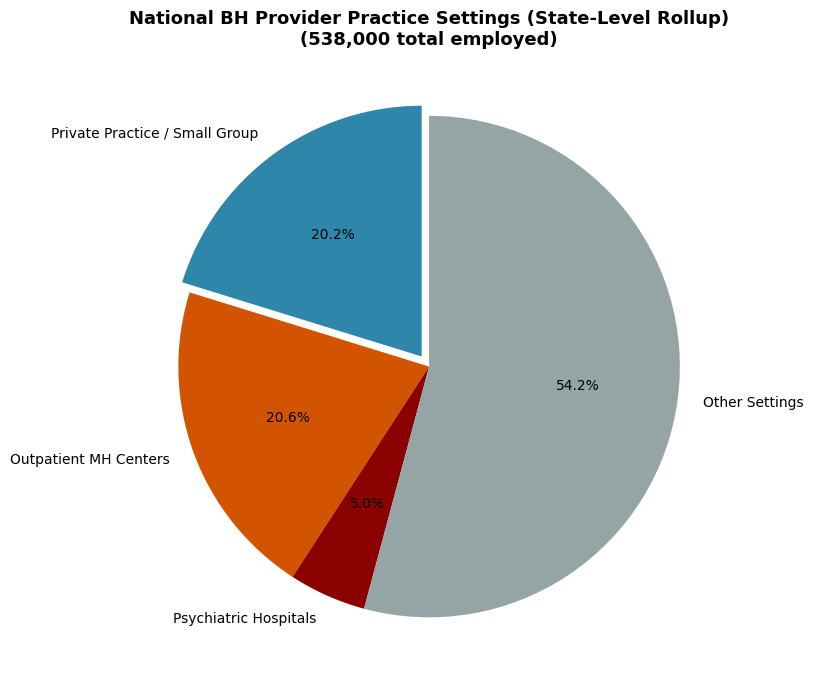

Saved: practice_settings_national_pie.png


In [11]:
# --- Chart 1: National pie chart ---
fig, ax = plt.subplots(figsize=(10, 7))

labels_pie = list(national_settings.keys())
sizes = list(national_settings.values())
colors_pie = ['#2E86AB', '#d35400', '#8B0000', '#95a5a6']
explode = (0.05, 0, 0, 0)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_pie, colors=colors_pie, explode=explode,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10}
)
ax.set_title(f'National BH Provider Practice Settings (State-Level Rollup)\n({total_bh:,.0f} total employed)',
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'practice_settings_national_pie.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: practice_settings_national_pie.png")

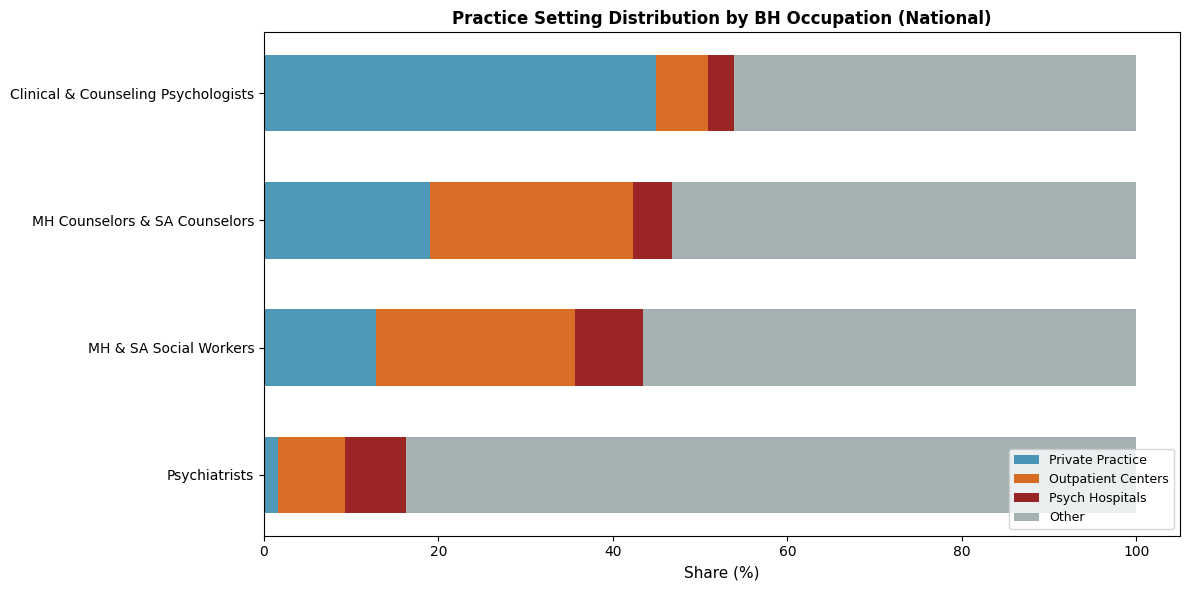

Saved: practice_settings_by_occupation.png


In [12]:
# --- Chart 2: Stacked horizontal bar by occupation ---
fig, ax = plt.subplots(figsize=(12, 6))

occ_names = df_by_occ['occupation'].tolist()
y_pos = range(len(occ_names))

lefts = [0] * len(occ_names)
bar_data = [
    ('Private Practice', 'private_practice_pct', '#2E86AB'),
    ('Outpatient Centers', 'outpatient_centers_pct', '#d35400'),
    ('Psych Hospitals', 'psych_hospitals_pct', '#8B0000'),
    ('Other', 'other_settings_pct', '#95a5a6'),
]

for label, col, color in bar_data:
    vals = df_by_occ[col].tolist()
    ax.barh(y_pos, vals, left=lefts, label=label, color=color, alpha=0.85, height=0.6)
    lefts = [l + v for l, v in zip(lefts, vals)]

ax.set_yticks(y_pos)
ax.set_yticklabels(occ_names, fontsize=10)
ax.set_xlabel('Share (%)', fontsize=11)
ax.set_title('Practice Setting Distribution by BH Occupation (National)', fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 105)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'practice_settings_by_occupation.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: practice_settings_by_occupation.png")

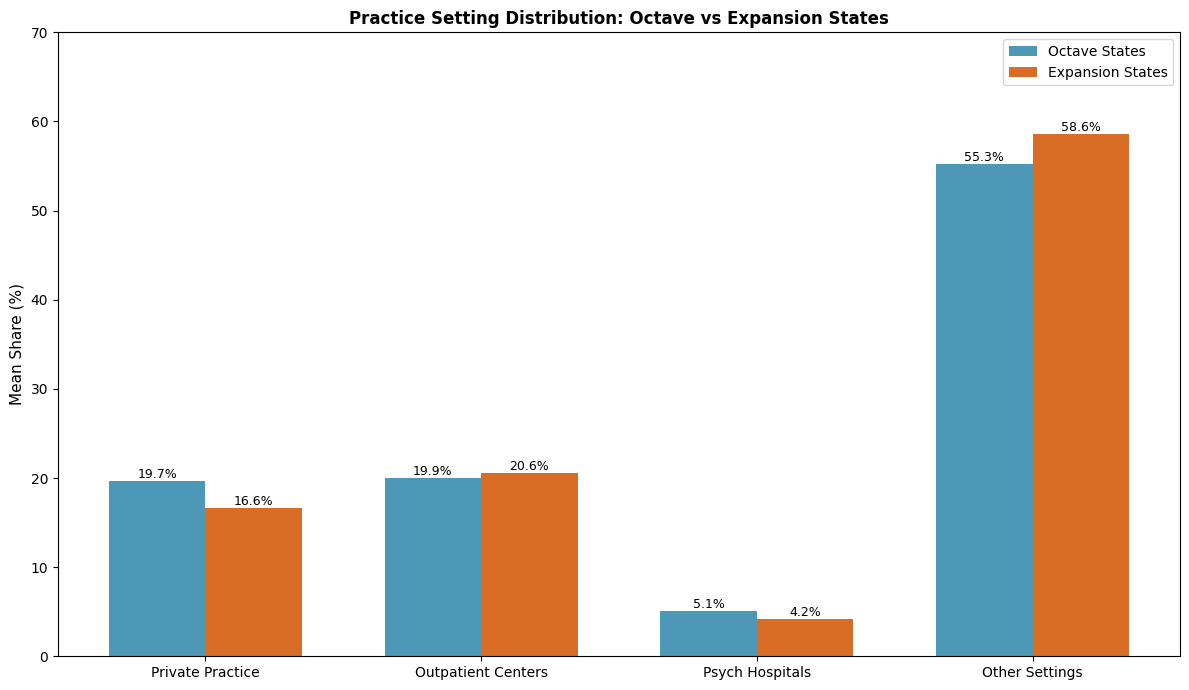

Saved: practice_settings_octave_vs_expansion.png


In [13]:
# --- Chart 3: State comparison (Octave vs Expansion by practice setting) ---
fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data
categories = ['Private Practice', 'Outpatient Centers', 'Psych Hospitals', 'Other Settings']
octave_means = [
    df_octave_grp['private_practice_pct'].mean(),
    df_octave_grp['outpatient_centers_pct'].mean(),
    df_octave_grp['psych_hospitals_pct'].mean(),
    df_octave_grp['other_settings_pct'].mean(),
]
expansion_means = [
    df_expansion_grp['private_practice_pct'].mean(),
    df_expansion_grp['outpatient_centers_pct'].mean(),
    df_expansion_grp['psych_hospitals_pct'].mean(),
    df_expansion_grp['other_settings_pct'].mean(),
]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, octave_means, width, label='Octave States', color='#2E86AB', alpha=0.85)
bars2 = ax.bar(x + width/2, expansion_means, width, label='Expansion States', color='#d35400', alpha=0.85)

ax.set_ylabel('Mean Share (%)', fontsize=11)
ax.set_title('Practice Setting Distribution: Octave vs Expansion States', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 70)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'practice_settings_octave_vs_expansion.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: practice_settings_octave_vs_expansion.png")

## 8. Save Outputs

In [14]:
# --- Save national summary ---
df_national = pd.DataFrame([
    {'setting': k, 'employment': v, 'share_pct': round(v / total_bh * 100, 1)}
    for k, v in national_settings.items()
])

summary_path = os.path.join(OUTPUT_DIR, 'provider_practice_settings_national.csv')
df_national.to_csv(summary_path, index=False)
print(f"Saved: provider_practice_settings_national.csv")
print(df_national)

# --- Save by-occupation detail ---
occ_path = os.path.join(OUTPUT_DIR, 'practice_settings_by_occupation.csv')
df_by_occ.to_csv(occ_path, index=False)
print(f"\nSaved: practice_settings_by_occupation.csv")
print(df_by_occ[['occupation', 'total', 'private_practice_pct', 'outpatient_centers_pct', 'psych_hospitals_pct', 'other_settings_pct']])

# --- Save state-level detail ---
state_path = os.path.join(OUTPUT_DIR, 'state_provider_practice_settings.csv')
df_state_summary.to_csv(state_path, index=False)
print(f"\nSaved: state_provider_practice_settings.csv ({len(df_state_summary)} rows)")
print(f"First 10 rows:")
print(df_state_summary[['area_title', 'total_bh', 'private_practice_pct', 'outpatient_centers_pct', 'psych_hospitals_pct', 'other_settings_pct', 'is_octave_state']].head(10))

print(f"\n{'='*70}")
print(f"DONE — 3 output files saved to {OUTPUT_DIR}")
print(f"{'='*70}")

Saved: provider_practice_settings_national.csv
                          setting  employment  share_pct
0  Private Practice / Small Group    108780.0       20.2
1           Outpatient MH Centers    110910.0       20.6
2           Psychiatric Hospitals     26830.0        5.0
3                  Other Settings    291480.0       54.2

Saved: practice_settings_by_occupation.csv
                            occupation     total  private_practice_pct  \
0  Clinical & Counseling Psychologists   61060.0                  45.0   
1        MH Counselors & SA Counselors  357360.0                  19.1   
2               MH & SA Social Workers   99590.0                  12.9   
3                        Psychiatrists   19990.0                   1.6   

   outpatient_centers_pct  psych_hospitals_pct  other_settings_pct  
0                     5.9                  3.0                46.1  
1                    23.2                  4.5                53.2  
2                    22.8                  7.7

## 9. Data Limitations

**State-level data quality.** BLS suppresses some cells for confidentiality reasons. When a state has very few providers in a particular setting/occupation combination, the count may be suppressed (shown as `**` in the source file). Our analysis aggregates to the state level which reduces suppressions, but some states with smaller BH workforces may have higher residuals.

**BLS OES excludes self-employed sole proprietors.** The OES survey only covers workers on
employer payrolls. A psychologist running a solo private practice who has not incorporated
is not counted. The true share of providers in independent practice is likely higher than
what this data shows.

**Practice setting does not equal availability or recruitability.** A provider employed by
a hospital system can also take telehealth clients through a platform like Octave on
evenings or weekends via a 1099 contractor arrangement. Conversely, a provider in private
practice with a full caseload may have no capacity for additional patients. This data
describes where providers are currently employed, not the recruitable supply.

**NAICS 621330 includes small group practices**, not just solo practitioners. An office
with 5 therapists sharing space and billing under one entity falls into this category.

**NAICS inconsistencies.** Private practice (621330) and outpatient centers
(621420) use 5-digit codes. Psychiatric hospitals use 4-digit code (622200) because
6-digit subdivisions may not be available in the state file. The total across all industries
comes from sector-level (NAICS=62). This mixing is necessary but may introduce minor
inconsistencies.

**This data is used for background context only.** It is NOT a dimension in the expansion
scoring model (NB07).